In [26]:
import os
import io
os.environ["KERAS_BACKEND"] = "torch"
import numpy as np
import pandas as pd
import pydicom as dicom
import zipfile
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import train_test_split
import keras
from keras import layers
from keras.metrics import Recall, Precision
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight
from scipy.ndimage import zoom


# -------------------
# CONFIG
# -------------------
DATA_ROOT = "processed_data"
Multi_scale_patch = True
IMAGE_FOLDER = os.path.join(DATA_ROOT, "images")
LABELS_FILE = os.path.join(DATA_ROOT, "labels.csv")



CONFIG = {
    "img_size": (64, 64, 1),
    "batch_size": 64,
    "epochs": 10,
    "learning_rate": 1e-4,
    "model_name": "multiscale",   # 👈 change this to switch model
}


In [27]:
# -------------------
# HELPERS
# -------------------
def get_model(name, input_shape):
    if name not in MODEL_REGISTRY:
        raise ValueError(f"Model '{name}' not found. Available: {list(MODEL_REGISTRY.keys())}")
    
    return MODEL_REGISTRY[name](input_shape)

def compile_model(model, config):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall(name="recall"), Precision(name="precision")]
    )
    return model

def load_data(df):

    if Multi_scale_patch:
        X_small = []
        X_large = []
        Y = []

        for _, row in df.iterrows():
            f_small = os.path.join(DATA_ROOT, "images_small", row["file_small"])
            f_large = os.path.join(DATA_ROOT, "images_large", row["file_large"])

            img_small = np.load(f_small)
            img_large = np.load(f_large)

            X_small.append(img_small)
            X_large.append(img_large)
            Y.append(row["label"])

        X_small = np.array(X_small)
        X_large = np.array(X_large)
        Y = np.array(Y, dtype=np.int32)

        return [X_small, X_large], Y

    else:
        X = []
        Y = []

        for _, row in df.iterrows():
            f = os.path.join(DATA_ROOT, "images", row["file"])

            img = np.load(f)

            X.append(img)
            Y.append(row["label"])

        X = np.array(X)
        Y = np.array(Y, dtype=np.int32)

        return X, Y

def residual_block(x, filters, stride=1):

    shortcut = x

    # main path
    x = layers.Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # adjust shortcut if needed
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x


# -------------------
# MODELS
# -------------------
def build_baseline(input_shape):
    return keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(16, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])


def build_deeper(input_shape):
    return keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 32, activation='relu'),
        layers.Conv2D(32, 32, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 32, activation='relu'),
        layers.Conv2D(64, 32, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 16, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

def build_stronger_model(input_shape):

    inputs = layers.Input(shape=input_shape)

    # --- Block 1 (bigger filters early) ---
    x = layers.Conv2D(32, 7, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # --- Block 2 ---
    x = layers.Conv2D(64, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # --- Block 3 ---
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # --- Block 4 (important for context) ---
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # --- Global pooling instead of flatten ---
    x = layers.GlobalAveragePooling2D()(x)

    # --- Dense head ---
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs)

def build_fcn_v2(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 7, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, 1, activation='relu')(x)

    # classification map
    x = layers.Conv2D(1, 1, activation='sigmoid')(x)

    # reduce to scalar
    x = layers.GlobalMaxPooling2D()(x)

    return keras.Model(inputs, x)

def build_deep_resnet_fcn(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # --- Stage 1 ---
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # --- Stage 2 ---
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    # --- Stage 3 ---
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # --- Stage 4 ---
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # --- FCN head ---
    x = layers.Conv2D(128, 1, activation='relu')(x)
    x = layers.Conv2D(1, 1, activation='sigmoid')(x)

    # --- global decision ---
    x = layers.GlobalMaxPooling2D()(x)

    return keras.Model(inputs, x)

def build_patch_cnn(input_shape=(64, 64, 1)):

    inputs = keras.Input(shape=input_shape)

    # --- Block 1 ---
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D()(x) 

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D()(x)  

  
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D()(x) 


    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs)

def build_multiscale_model(input_shape):

    # --- INPUTS ---
    inp1 = keras.Input(shape=input_shape)  # small
    inp2 = keras.Input(shape=input_shape)  # large (downsampled)

    # --- SHARED FEATURE EXTRACTOR ---
    def branch(x):
        x = layers.Conv2D(32, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(64, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(128, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.GlobalAveragePooling2D()(x)

        return x

    # --- APPLY TO BOTH SCALES ---
    f1 = branch(inp1)
    f2 = branch(inp2)

    # --- MERGE ---
    x = layers.Concatenate()([f1, f2])

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model([inp1, inp2], out)

MODEL_REGISTRY = {
    "baseline": build_baseline,
    "deeper": build_deeper,
    "strong": build_stronger_model,
    "FCN": build_fcn_v2,
    "DFCN": build_deep_resnet_fcn,
    "PatchCNN": build_patch_cnn,
    "multiscale": build_multiscale_model
}

In [ ]:
# -------------------
# LOAD LABELS
# -------------------
df = pd.read_csv(LABELS_FILE)

print("Total samples:", len(df))
print(df['label'].value_counts())

# -------------------
# SPLIT
# -------------------
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

# -------------------
# LOAD INTO MEMORY
# -------------------
X_train, Y_train = load_data(train_df)
X_val, Y_val = load_data(val_df)
X_test, Y_test = load_data(test_df)

if Multi_scale_patch:
    print("Train:", X_train[0].shape)
    print("Train:", X_train[1].shape)
else:
    print("Train:", X_train.shape)
print("Train balance:", np.mean(Y_train))
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Total samples: 46525
label
0    23833
1    22692
Name: count, dtype: int64


AttributeError: 'list' object has no attribute 'shape'

In [28]:
# -------------------
# Model training
# -------------------
# build model
model = get_model(CONFIG["model_name"],CONFIG["img_size"]) 

# compile
model = compile_model(model, CONFIG)

model.summary()

# train
if Multi_scale_patch:
    history = model.fit(
        [X_train[0],X_train[1]], Y_train,
        validation_data=([X_val[0],X_val[1]], Y_val),
        epochs=CONFIG["epochs"],
        batch_size=CONFIG["batch_size"],
    )
    y_pred_probs = model.predict([X_test[0],X_test[1]])
else:
    history = model.fit(
    X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=CONFIG["epochs"],
        batch_size=CONFIG["batch_size"],
    )
    y_pred_probs = model.predict(X_test)
# get predictions (probabilities)


# convert to binary (threshold = 0.5)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = Y_test.astype(int)

# -------------------
# PER-LABEL ACCURACY
# -------------------
for label in [0, 1]:
    idx = (y_true == label)
    
    if np.sum(idx) == 0:
        print(f"Label {label}: no samples")
        continue

    acc = np.mean(y_pred[idx] == y_true[idx])
    print(f"Accuracy for label {label}: {acc:.4f} (n={np.sum(idx)})")

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# pretty print
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
# test
model.evaluate(X_test, Y_test)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 64, 64,    │        320 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 64, 64,    │        320 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_50[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_41       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_44       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 32, 32,    │          0 │ activation_41[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 32, 32,    │          0 │ activation_44[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_15… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_17… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_51[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_42       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_45       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 16, 16,    │          0 │ activation_42[0]

 Total params: 203,649 (795.50 KB)

 Trainable params: 202,753 (792.00 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7233 - loss: 0.5577 - precision: 0.7006 - recall: 0.7555 - val_accuracy: 0.6816 - val_loss: 0.6203 - val_precision: 0.7397 - val_recall: 0.5358
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7335 - loss: 0.5431 - precision: 0.7074 - recall: 0.7736 - val_accuracy: 0.7220 - val_loss: 0.5426 - val_precision: 0.7448 - val_recall: 0.6542
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7380 - loss: 0.5345 - precision: 0.7112 - recall: 0.7794 - val_accuracy: 0.7415 - val_loss: 0.5323 - val_precision: 0.7093 - val_recall: 0.7964
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7415 - loss: 0.5299 - precision: 0.7125 - recall: 0.7878 - val_accuracy: 0.7352 - val_loss: 0.5301 - val_precision: 0.6874 - val_recall: 0.8384
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7457 - loss: 0.5245 - precision: 0.7181 - recall: 0.7879 - val_accuracy: 0.7470 - va

[0.5060913562774658, 0.74982088804245, 0.8228554725646973, 0.7101926803588867]

Selected image: 41040a367358df02680bc6ce2ab7475b


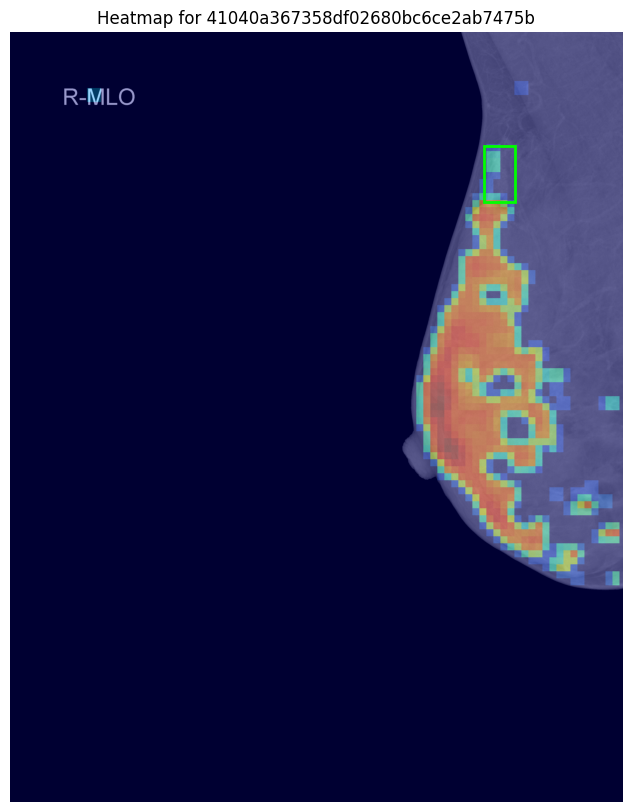

In [15]:
# -------------------
# CONFIG (adjust these)
# -------------------
Load_from_ZIP = True
zip_path = "data/vindr-mammo-a-large-scale-benchmark-dataset-for-computer-aided-detection-and-diagnosis-in-full-field-digital-mammography-1.0.0.zip"
image_folder = "data/train_images/"
patch_size = (64, 64)
stride = 32

# -------------------
# LOAD CSV (must exist already)
# -------------------
df = pd.read_csv("data/finding_annotations.csv")
df = df[['image_id','finding_categories','xmin','ymin','xmax','ymax']]

# -------------------
# BUILD IMAGE INDEX
# -------------------
image_index = {}

if Load_from_ZIP:
    z = zipfile.ZipFile(zip_path)
    for name in z.namelist():
        if name.endswith(".dicom"):
            image_id = os.path.basename(name).replace(".dicom", "")
            image_index[image_id] = name
else:
    for root, dirs, files in os.walk(image_folder):
        for file in files:
            if file.endswith(".dicom"):
                image_id = file.replace(".dicom", "")
                image_index[image_id] = os.path.join(root, file)

# -------------------
# LOAD + FIX IMAGE
# -------------------
def load_image(image_id):
    if image_id not in image_index:
        return None

    try:
        if Load_from_ZIP:
            with z.open(image_index[image_id]) as f:
                ds = dicom.dcmread(io.BytesIO(f.read()))
        else:
            ds = dicom.dcmread(image_index[image_id])

        img = ds.pixel_array.astype(np.float32)

        # normalize
        img = (img - img.min()) / (img.max() - img.min() + 1e-6)

        # fix inversion
        if hasattr(ds, "PhotometricInterpretation"):
            if ds.PhotometricInterpretation == "MONOCHROME1":
                img = 1.0 - img
        else:
            if np.mean(img) > 0.6:
                img = 1.0 - img

        return img

    except Exception as e:
        print("Error:", e)
        return None

# -------------------
# HEATMAP GENERATION
# -------------------
def generate_heatmap(model, img):
    h, w = img.shape
    heatmap = np.zeros((h, w))
    counts = np.zeros((h, w))

    for y in range(0, h - patch_size[0] + 1, stride):
        for x in range(0, w - patch_size[1] + 1, stride):

            patch = img[y:y+patch_size[0], x:x+patch_size[1]]

            patch_input = np.expand_dims(patch, axis=(0, -1))

            pred = model.predict(patch_input, verbose=0)[0][0]
            pred = 0 if (max(0.5, pred) == 0.5) else pred
            heatmap[y:y+patch_size[0], x:x+patch_size[1]] += pred
            counts[y:y+patch_size[0], x:x+patch_size[1]] += 1

    heatmap = heatmap / (counts + 1e-6)

    return heatmap

# -------------------
# VISUALIZATION
# -------------------
def show_heatmap(model, image_id):
    img = load_image(image_id)

    if img is None:
        print("Image not found")
        return

    heatmap = generate_heatmap(model, img)

    plt.figure(figsize=(10,10))
    plt.imshow(img, cmap='gray')

    # overlay heatmap
    plt.imshow(heatmap, cmap='jet', alpha=0.4)

    # draw GT boxes
    rows = df[df['image_id'] == image_id]

    for _, row in rows.iterrows():
        if row['finding_categories'] == "['Mass']" and not np.isnan(row['xmin']):
            x = row['xmin']
            y = row['ymin']
            w = row['xmax'] - row['xmin']
            h = row['ymax'] - row['ymin']

            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor='lime',
                facecolor='none'
            )
            plt.gca().add_patch(rect)

    plt.title(f"Heatmap for {image_id}")
    plt.axis('off')
    plt.show()

def get_random_mass_image_id(df):
    # keep only rows with Mass and valid boxes
    mass_df = df[
        (df['finding_categories'] == "['Mass']") &
        (~df['xmin'].isna())
    ]

    if len(mass_df) == 0:
        print("No Mass images found in dataframe")
        return None

    # get unique image_ids
    image_ids = mass_df['image_id'].unique()

    # pick one randomly
    return np.random.choice(image_ids)
# -------------------
# RUN (random image)
# -------------------
image_id = get_random_mass_image_id(df)



if image_id is not None:
    print("Selected image:", image_id)
    show_heatmap(model, image_id)